In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from skbio.stats.ordination import pcoa
from skbio import DistanceMatrix
from skbio.stats.distance import permanova
from skbio.stats.distance import permdisp
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms


from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import warnings
from upsetplot import from_contents, UpSet

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)


from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [ ]:
# ── DATA DIRECTORY ──────────────────────────────────────────────────────────
# Update this path if you cloned the repo to a different location.
# In WSL, your OneDrive Documents typically maps to:
DATA_DIR = "/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22"
DESEQ2_DIR = f"{DATA_DIR}/DeSeq2"
TPM_DIR    = f"{DATA_DIR}/Arquivos brutos/TPM"
GENOME_DIR = f"{DATA_DIR}/Arquivos brutos/genomes_9a5c_temecula1"


In [2]:
cd /mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/genomes_9a5c_temecula1

/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/genomes_9a5c_temecula1


PERMANOVA: method name               PERMANOVA
test statistic name        pseudo-F
sample size                      24
number of groups                  2
test statistic             2.688834
p-value                       0.036
number of permutations          999
Name: PERMANOVA results, dtype: object
PERMDISP: method name               PERMDISP
test statistic name        F-value
sample size                     24
number of groups                 2
test statistic            0.711351
p-value                      0.513
number of permutations         999
Name: PERMDISP results, dtype: object


/tmp/ipykernel_27393/1713024755.py:77: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_xlabel(f"PC1 ({pcoa_res.proportion_explained[0]*100:.1f}% var)")
/tmp/ipykernel_27393/1713024755.py:78: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_ylabel(f"PC2 ({pcoa_res.proportion_explained[1]*100:.1f}% var)")


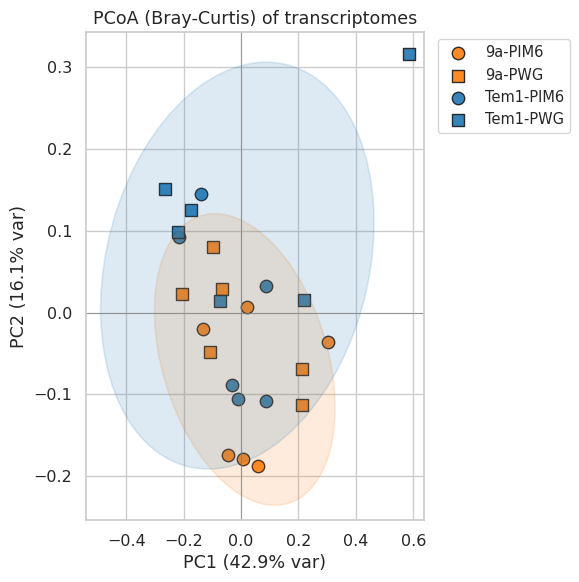

In [3]:
# Figure 3A - PCoA (Bray-Curtis) static plot (publication-ready)
# Load matrix: rows = genes/features, columns = samples OR vice-versa.
# In your script you used transcriptome_pcoa = pd.read_csv('matrix_9a5c_Temecula1.csv', sep=";", index_col=0)
# and then transposed into transcriptome_pcoa_t. Ensure shape: rows = samples, cols = features for pdist.
mat = pd.read_csv('matrix_9a5c_Temecula1.csv', sep=';', index_col=0).T  # now rows=samples
# Compute Bray-Curtis distances
bc = pdist(mat.values, metric='braycurtis')
dm = DistanceMatrix(squareform(bc), ids=mat.index.tolist())

# PCoA
pcoa_res = pcoa(dm)
coords = pcoa_res.samples.iloc[:, :2]  # PC1, PC2
coords.columns = ['PC1','PC2']

# Metadata: build a DataFrame with columns 'strain','medium','time','phase' matching sample order
# Example parse from sample names (adapt to your naming convention)
def parse_sample_name(s):
    # Expect patterns like '9a_PIM6_1d_1' or 'Tem1_PWG_7d_3'
    parts = s.split('_')
    strain = parts[0]  # '9a' or 'Tem1' depending on naming
    medium = parts[1]  # e.g., 'PIM6' or 'PWG'
    # extract day number from parts[2] like '1d' or '7d'
    day = int(''.join([c for c in parts[2] if c.isdigit()]))
    return strain, medium, day

meta = []
for s in mat.index:
    st, md, day = parse_sample_name(s)
    meta.append({'sample': s, 'strain': st, 'medium': md, 'day': day})
meta_df = pd.DataFrame(meta).set_index('sample').loc[coords.index]

# PERMANOVA and PERMDISP (grouping by strain or other factor)
# Example grouping by "strain"
permanova_res = permanova(dm, grouping=meta_df['strain'])
permdisp_res = permdisp(dm, meta_df['strain'], permutations=999)  # returns dispersion test object

print("PERMANOVA:", permanova_res)
print("PERMDISP:", permdisp_res)

# Plot static PCoA
sns.set(style='whitegrid', font_scale=1.05)
fig, ax = plt.subplots(figsize=(6,6))

palette = {'9a':'tab:orange', 'Tem1':'tab:blue', '9a5c':'tab:orange','Temecula1':'tab:blue'}  # adapt names
markers = {'PIM6': 'o', 'PWG': 's'}

for (strain, medium), group in meta_df.groupby(['strain','medium']):
    idx = group.index
    ax.scatter(coords.loc[idx,'PC1'], coords.loc[idx,'PC2'],
               label=f"{strain}-{medium}",
               s=80,
               color=palette.get(strain, 'grey'),
               marker=markers.get(medium, 'o'),
               edgecolor='k', alpha=0.9)

# Draw 95% confidence ellipses for each strain (optional)
def draw_ellipse(x, y, ax, facecolor='none', edgecolor='k', alpha=0.3):
    if len(x) <= 2:
        return
    cov = np.cov(x, y)
    mean = [np.mean(x), np.mean(y)]
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(*eigvecs[:,0][::-1]))
    # 2 standard deviations ~ 95% ellipse
    width, height = 2 * 2 * np.sqrt(eigvals)
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  edgecolor=edgecolor, facecolor=facecolor, lw=1.2, alpha=alpha)
    ax.add_patch(ell)

for strain, g in meta_df.groupby('strain'):
    draw_ellipse(coords.loc[g.index,'PC1'].values, coords.loc[g.index,'PC2'].values, ax,
                 facecolor=palette.get(strain,'none'), edgecolor=palette.get(strain,'k'), alpha=0.15)

ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel(f"PC1 ({pcoa_res.proportion_explained[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pcoa_res.proportion_explained[1]*100:.1f}% var)")
ax.set_title("PCoA (Bray-Curtis) of transcriptomes")

# Clean legend: group by strain/medium labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(loc='best', fontsize='small', frameon=True, bbox_to_anchor=(1.02,1))

plt.tight_layout()
# plt.savefig("Figure3A_PCoA_BrayCurtis.tiff", dpi=600, bbox_inches='tight')
plt.show()


In [4]:
cd /mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/TPM

/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/TPM


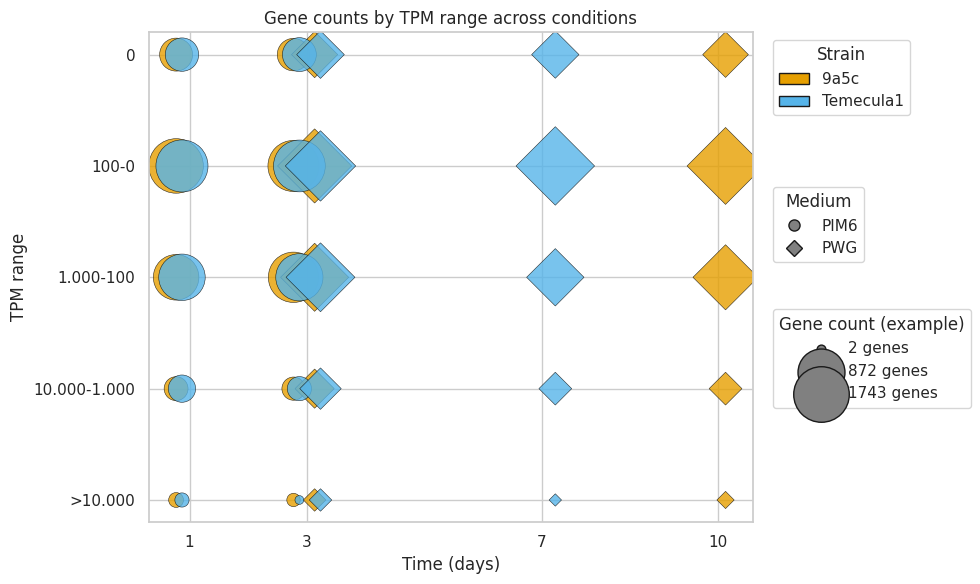

In [6]:
# Figure 3B - Bubble plot: gene counts by TPM range (improved)


# If you ran process_tpm_files() already and got tpm_summary DataFrame, load it:
tpm_summary = pd.read_csv("tpm_ranges_summary.csv")  # or use variable from memory

# map times to numeric and add jitter offsets as you already did
jitter_map_medium = {'PIM6': -0.18, 'PWG': 0.18}
jitter_map_strain = {'9a5c': -0.05, 'Temecula1': 0.05}
tpm_summary['jitter_time'] = tpm_summary['time(days)'] + tpm_summary['culture medium'].map(jitter_map_medium) + tpm_summary['strain'].map(jitter_map_strain)

# Melt
cols = [">10.000","10.000-1.000","1.000-100","100-0","0"]
df_melted = tpm_summary.melt(id_vars=['strain','culture medium','time(days)','jitter_time'], value_vars=cols,
                             var_name='TPM_range', value_name='gene_count')

# define order for TPM_range if desired
range_order = [">10.000","10.000-1.000","1.000-100","100-0","0"]
df_melted['TPM_range'] = pd.Categorical(df_melted['TPM_range'], categories=range_order, ordered=True)

# sizes: map 'gene_count' to bubble area (s in scatter = area). Use sqrt scale to even out extremes
min_size, max_size = 40, 1600
gc_min, gc_max = df_melted['gene_count'].min(), df_melted['gene_count'].max()
def scale_size(x):
    if gc_max == gc_min:
        return (min_size+max_size)/2
    # square-root scaling for perceptual area
    return min_size + (np.sqrt(x - gc_min) / (np.sqrt(gc_max - gc_min))) * (max_size - min_size)
df_melted['size'] = df_melted['gene_count'].apply(scale_size)

# plotting
sns.set(style='whitegrid', font_scale=1.0)
fig, ax = plt.subplots(figsize=(10,6))

palette = {'9a5c': '#E69F00', 'Temecula1': '#56B4E9'}  # colorblind-friendly pair

# scatter with different markers for medium
markers = {'PIM6':'o', 'PWG':'D'}

for (strain, medium), group in df_melted.groupby(['strain','culture medium']):
    ax.scatter(group['jitter_time'], group['TPM_range'], s=group['size'],
               color=palette.get(strain, 'grey'), marker=markers.get(medium,'o'),
               edgecolor='black', alpha=0.8, linewidth=0.4, label=f"{strain}-{medium}")

# Build custom legends:
# 1) Legend for strain colors
strain_handles = [Patch(facecolor=palette[k], edgecolor='k', label=k) for k in palette]
# 2) Legend for medium markers
marker_handles = [Line2D([0],[0], marker=markers[m], color='w', markerfacecolor='grey',
                         markeredgecolor='k', markersize=8, label=m) for m in markers]
# 3) Legend for sizes (choose representative counts)
size_legend_counts = [int(gc_min), int((gc_min+gc_max)/2), int(gc_max)]
size_handles = [plt.scatter([],[], s=scale_size(c), color='gray', edgecolor='k') for c in size_legend_counts]

# place legends
legend1 = ax.legend(handles=strain_handles, title='Strain', loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=True)
legend2 = ax.legend(handles=marker_handles, title='Medium', loc='upper left', bbox_to_anchor=(1.02, 0.7), frameon=True)
legend3 = ax.legend(size_handles, [f"{c} genes" for c in size_legend_counts], title='Gene count (example)', loc='upper left', bbox_to_anchor=(1.02, 0.45), frameon=True)
ax.add_artist(legend1)
ax.add_artist(legend2)

# x-axis: show actual time points (sorted unique times)
xticks = sorted(tpm_summary['time(days)'].unique())
ax.set_xticks(xticks)
ax.set_xlabel('Time (days)')
ax.set_ylabel('TPM range')
ax.set_title('Gene counts by TPM range across conditions')

plt.tight_layout()
# plt.savefig('Figure3B_Bubble_TPM.tiff', dpi=600, bbox_inches='tight')
plt.show()


In [7]:
pwd

'/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/TPM'

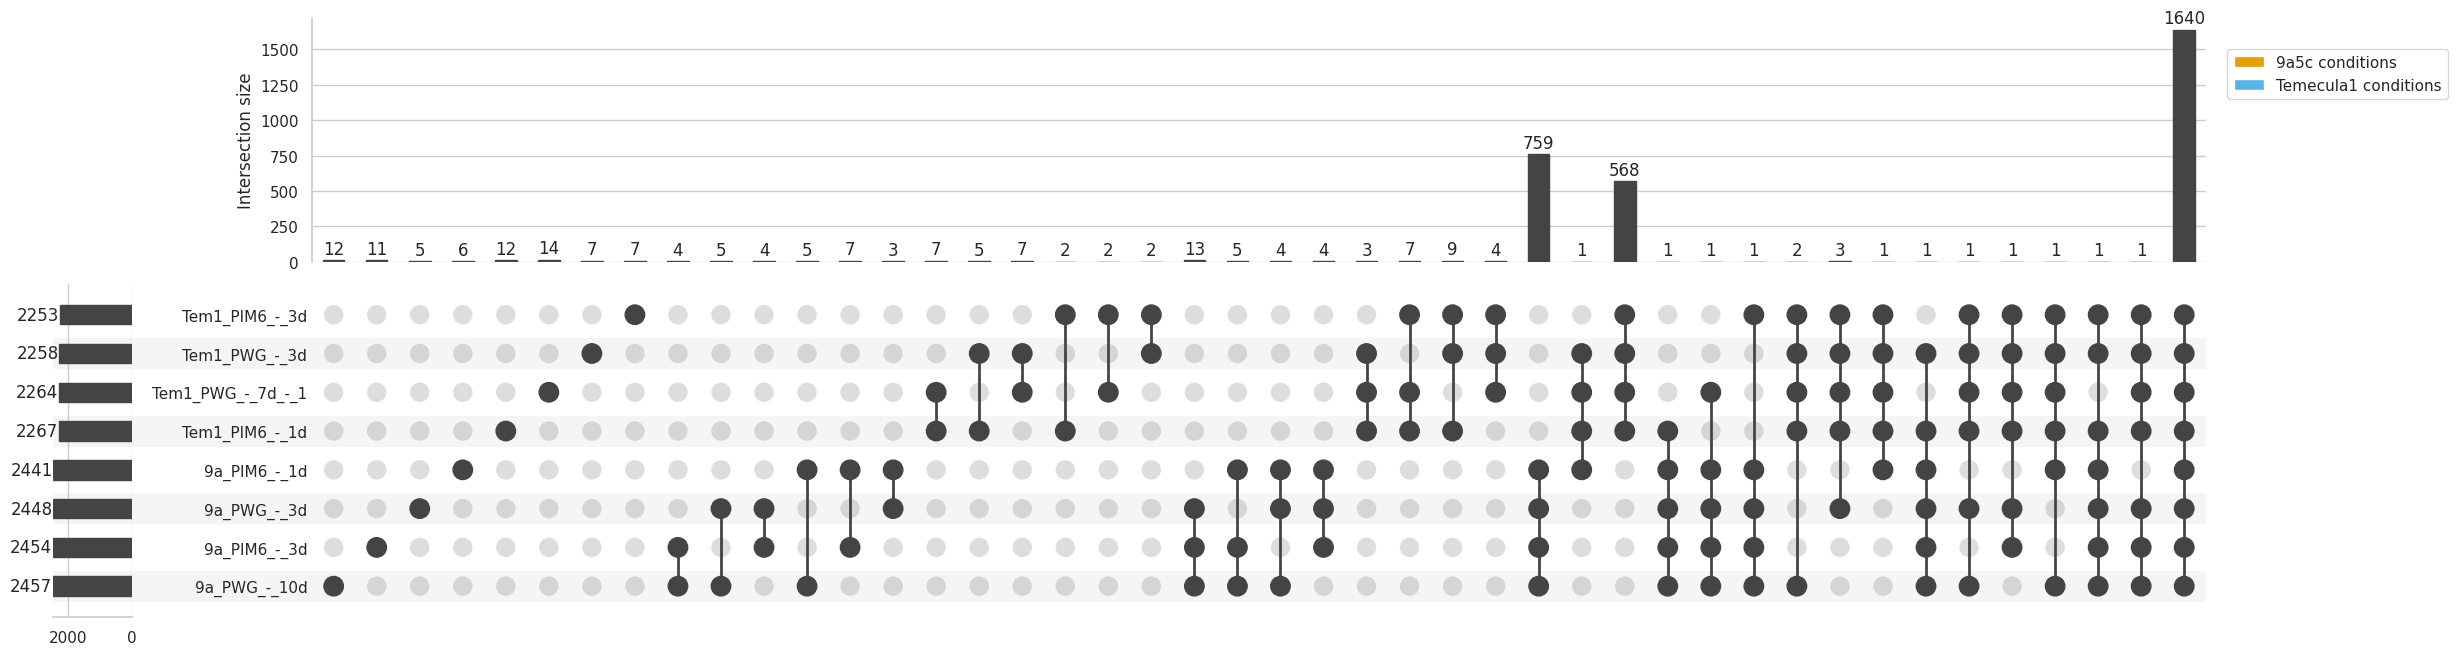

In [9]:
# Figure 3C - UpSet of gene presence across conditions (cleaned)
# --- Input files (update paths if needed) ---
fn_9a = "table_9a_avg_tpm.csv"
fn_tem = "table_tem_avg_tpm.csv"
fn_dict = "gene_dictionary.csv"

# --- 1) Load TPM tables robustly ---
def load_tpm_table(path, strain_prefix):
    df = pd.read_csv(path, sep="\t", dtype=str)    # read as strings first to handle commas
    # find the column that contains the gene name (try common names)
    name_col = next((c for c in df.columns if c.lower() in ("name", "gene", "gene_id", "id")), df.columns[0])
    # convert numeric columns (everything except name_col) to floats with comma handling
    for c in df.columns:
        if c == name_col:
            continue
        df[c] = df[c].astype(str).str.replace(",", ".").replace("nan", "0").astype(float)
    # rename columns to include strain prefix (except the name column)
    rename_map = {c: f"{strain_prefix}_{c.strip().replace(' ', '_')}" for c in df.columns if c != name_col}
    df = df.rename(columns=rename_map)
    df = df.rename(columns={name_col: "Name"})
    return df

df_9a = load_tpm_table(fn_9a, "9a")
df_tem = load_tpm_table(fn_tem, "Tem1")

# --- 2) Load mapping dictionary and build unified gene names ---
map_df = pd.read_csv(fn_dict, sep="\t", dtype=str).fillna("")  # tolerant to missing values

# create unified name using IMG IDs when available, else fallback to locus tags/product
map_df["unified_gene_name"] = (
    map_df["9a5c_IMG_ID"].astype(str).str.strip() + "_" + map_df["Temecula1_IMG_ID"].astype(str).str.strip()
).str.strip("_")
# if result is empty string (neither IMG present), fallback to concatenating locus tags
empty_mask = map_df["unified_gene_name"] == ""
map_df.loc[empty_mask, "unified_gene_name"] = (
    map_df.loc[empty_mask, "9a5c_locus_tag"].astype(str).str.strip() + "_" +
    map_df.loc[empty_mask, "Temecula1_locus_tag"].astype(str).str.strip()
).str.strip("_")
# final fallback: index-based unique name
map_df["unified_gene_name"] = map_df["unified_gene_name"].replace("", np.nan)
mask_nan = map_df["unified_gene_name"].isna()
map_df.loc[mask_nan, "unified_gene_name"] = ["UNMAPPED_" + str(i) for i in map_df.index[mask_nan]]

# build maps from IMG_ID -> unified_name
dict_9a = map_df.set_index("9a5c_IMG_ID")["unified_gene_name"].to_dict()
dict_tem = map_df.set_index("Temecula1_IMG_ID")["unified_gene_name"].to_dict()

# --- 3) Map names in TPM tables to unified names, preserving exclusives ---
def map_unified(df, mapping_dict, strain_suffix):
    # create a column unified_gene_name by mapping the Name column via mapping_dict
    df["unified_gene_name"] = df["Name"].map(mapping_dict)
    # mark unmapped as "<original>_<strain>_only"
    unmapped_mask = df["unified_gene_name"].isna()
    if unmapped_mask.any():
        df.loc[unmapped_mask, "unified_gene_name"] = df.loc[unmapped_mask, "Name"].astype(str) + f"_{strain_suffix}_only"
    return df.drop(columns=["Name"])

df_9a = map_unified(df_9a, dict_9a, "9a_only")
df_tem = map_unified(df_tem, dict_tem, "Tem_only")

# --- 4) Merge into wide table (outer), fill missing TPM with 0 ---
df_wide = pd.merge(df_9a, df_tem, on="unified_gene_name", how="outer")
# move unified_gene_name to index for convenience
df_wide = df_wide.set_index("unified_gene_name")
# convert all columns to numeric (they should already be), fill NaNs with 0
df_wide = df_wide.apply(pd.to_numeric, errors='coerce').fillna(0.0)

# Save intermediate file (optional)
df_wide.reset_index().to_csv("upset_input_with_exclusives.csv", index=False)

# --- 5) Build boolean presence/absence matrix (TPM > 0) ---
df_bool = (df_wide > 0).astype(bool)

# --- 6) Create memberships for upsetplot.from_contents ---
# from_contents expects a dict: set_name -> set_of_genes_present_in_that_set
data_for_plot = {}
for col in df_bool.columns:
    present_genes = df_bool.index[df_bool[col]].tolist()
    data_for_plot[col] = set(present_genes)

# Optionally reduce to top intersections (if too many)
# We will create UpSet object with a limit on number of intersections to display (max_degree)
memberships = from_contents(data_for_plot)

# --- 7) Plot UpSet (clean, with legends for strain/medium) ---
# Decide colors for conditions by strain prefix (9a_ vs Tem1_)
condition_colors = {}
for c in memberships.columns:
    if c.startswith("9a_"):
        condition_colors[c] = "#E69F00"   # orange for 9a5c
    elif c.startswith("Tem1_"):
        condition_colors[c] = "#56B4E9"   # blue for Temecula1
    else:
        condition_colors[c] = "#888888"

# Create UpSet object
upset = UpSet(memberships, sort_by="degree", show_counts=True, element_size=40, facecolor="#444444")
# Plot
fig = plt.figure(figsize=(10,6))
ax_dict = upset.plot(fig=fig)

# ax_dict is a dict of Axes; keys vary with upsetplot version. We will add a manual legend on the figure:
legend_elems = [Patch(facecolor="#E69F00", label="9a5c conditions"),
                Patch(facecolor="#56B4E9", label="Temecula1 conditions")]
# put legend to the right of the figure
fig.legend(handles=legend_elems, loc='upper right', bbox_to_anchor=(0.99, 0.85))

plt.tight_layout()
# plt.savefig("Figure3C_UpSet.png", dpi=600, bbox_inches='tight')
plt.show()

# print("UpSet plot saved to Figure3C_UpSet.png")


In [12]:
cd /mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/TPM

/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/TPM


In [19]:
ls

'Gene Counts.tiff'*
 Gene_Counts_TPM.tiff*
 PIM6_gene_expression_plot.png*
 PWG_gene_expression_plot.png*
'Resumo-TPM values.xlsx'*
 TPM.txt*
 anova_fdr_results.csv*
 anova_fdr_results_v2.csv*
 combined_gene_expression_plot.png*
 equivalence_9a5c_Temecula1_transcriptome_cond.xlsx*
 figure_2.pdf*
 gene_dictionary.csv*
 gene_expression_trends.png*
 gene_expression_trends.tiff*
 table_9a_avg_tpm.csv*
 table_9a_b4_avg_tpm.csv*
 table_tem_avg_tpm.csv*
 table_tem_b4_avg_tpm.csv*
 tpm_ranges_summary.csv*
 tukey_pairwise_results.csv*
 tukey_pairwise_results_v2.csv*
 upset_input_with_exclusives.csv*
 upset_plot_color_strain.png*
 upset_plot_manual.png*
 virulence_genes_gene_expression_trends.png*
 virulence_genes_gene_expression_trends.tiff*
 virulence_table.csv*


Loading gene dictionary: gene_dictionary.csv
  loading: table_9a_b4_avg_tpm.csv as 9a5c
  loading: table_tem_b4_avg_tpm.csv as Temecula1
  done: rows= 66495 unique genes= 3422
Top 100 genes selected: 100


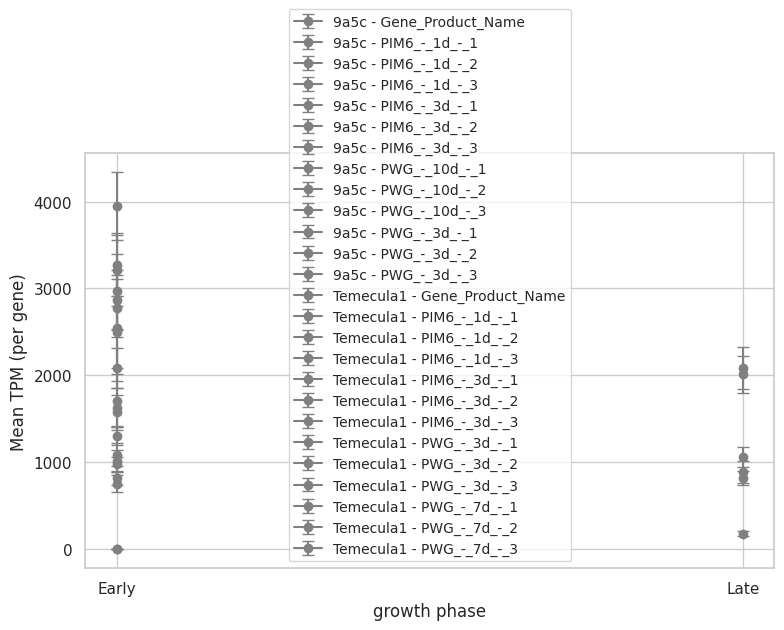

In [26]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings("ignore")
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd

def to_float_safe(series):
    return pd.to_numeric(series.astype(str).str.replace(",", "."), errors='coerce')

def build_unified_tpm_table(fn_9a="table_9a_b4_avg_tpm.csv",
                            fn_tem="table_tem_b4_avg_tpm.csv",
                            fn_dict="gene_dictionary.csv",
                            name_col_candidates=("Name","name","Gene","gene","ID","id")):
    print("Loading gene dictionary:", fn_dict)
    map_df = pd.read_csv(fn_dict, sep="\t", dtype=str).fillna("")
    if "unified_gene_name" not in map_df.columns:
        map_df["unified_gene_name"] = (map_df.get("9a5c_IMG_ID","").astype(str).str.strip() + "_" +
                                       map_df.get("Temecula1_IMG_ID","").astype(str).str.strip()).str.strip("_")
        mask = map_df["unified_gene_name"] == ""
        if mask.any():
            map_df.loc[mask, "unified_gene_name"] = [f"UNMAPPED_{i}" for i in map_df.index[mask]]

    map_9a = {k:v for k,v in zip(map_df.get("9a5c_IMG_ID",""), map_df["unified_gene_name"]) if k}
    map_tem = {k:v for k,v in zip(map_df.get("Temecula1_IMG_ID",""), map_df["unified_gene_name"]) if k}

    def load_and_melt(fn, strain_label):
        print("  loading:", fn, "as", strain_label)
        df = pd.read_csv(fn, sep="\t", dtype=str).fillna("")
        name_col = next((c for c in df.columns if c in name_col_candidates), df.columns[0])
        for c in df.columns:
            if c == name_col: continue
            df[c] = to_float_safe(df[c]).fillna(0.0)
        value_cols = [c for c in df.columns if c != name_col]
        ren = {c: f"{strain_label}__{c.strip().replace(' ', '_')}" for c in value_cols}
        df = df.rename(columns=ren)
        if strain_label.startswith("9a"):
            df["unified_gene"] = df[name_col].map(map_9a).fillna(df[name_col].astype(str)+"_"+strain_label)
        else:
            df["unified_gene"] = df[name_col].map(map_tem).fillna(df[name_col].astype(str)+"_"+strain_label)
        melted = df.melt(id_vars=["unified_gene"], value_vars=ren.values(), var_name="sample_col", value_name="tpm")
        # ensure string and robust split: remove "strain__" prefix -> keep the rest
        melted["sample_col"] = melted["sample_col"].astype(str)
        melted["sample_col_short"] = melted["sample_col"].str.split("__", n=1).str.get(1)
        # fallback if split failed
        melted["sample_col_short"] = melted["sample_col_short"].fillna(melted["sample_col"])
        # derive condition and replicate
        melted["condition"] = melted["sample_col_short"].str.replace(r"\s*-\s*\d+$", "", regex=True).str.strip()
        melted["replicate"] = melted["sample_col_short"].str.extract(r"(\d+)$").fillna("1").astype(str)
        melted["strain"] = strain_label
        melted["tpm"] = melted["tpm"].astype(float).fillna(0.0)
        return melted[["unified_gene","strain","condition","replicate","tpm"]]

    tbl_9a = load_and_melt(fn_9a, "9a5c")
    tbl_tem = load_and_melt(fn_tem, "Temecula1")
    combined = pd.concat([tbl_9a, tbl_tem], ignore_index=True)
    combined["strain_condition"] = combined["strain"] + "__" + combined["condition"]
    print("  done: rows=", len(combined), "unique genes=", combined['unified_gene'].nunique())
    return combined, map_df

# small helper functions (same as in previous cell)
def select_top_shared_genes(long_tpm_df, top_n=100, require_in_both_strains=True):
    mean_per_gene = long_tpm_df.groupby("unified_gene")["tpm"].mean()
    if require_in_both_strains:
        presence = long_tpm_df.groupby(["unified_gene","strain"]).size().unstack(fill_value=0)
        shared_mask = (presence>0).all(axis=1)
        candidates = mean_per_gene[shared_mask]
    else:
        candidates = mean_per_gene
    top = candidates.sort_values(ascending=False).head(top_n).index.tolist()
    return top

import re

def infer_phase_from_string(s):
    """Return 'early' or 'late' inferred from strings like 'PIM6 - 1d - 1' or 'PWG - 10d - 2'."""
    if not isinstance(s, str) or s.strip() == "":
        return ""
    s = s.lower()
    # common early markers: 1d, early
    if re.search(r'\b1d\b', s) or 'early' in s:
        return 'early'
    # common late markers: 3d, 7d, 10d, late
    if re.search(r'\b(3d|7d|10d|15d|21d)\b', s) or 'late' in s:
        return 'late'
    # fallback heuristics: smaller day => early
    m = re.search(r'(\d+)\s*d', s)
    if m:
        day = int(m.group(1))
        return 'early' if day <= 3 else 'late'
    return ''

def plot_figure4A(long_tpm_df, top_genes, out="Figure4A_top100.tiff"):
    """
    Robust plotting: handles variable 'condition' formats and missing parts.
    Aggregates per gene per condition then plots mean +/- SE across genes.
    """
    df = long_tpm_df[long_tpm_df["unified_gene"].isin(top_genes)].copy()
    if df.empty:
        raise RuntimeError("No data for requested genes.")
    # per gene per condition mean
    agg = df.groupby(["strain","condition","unified_gene"])["tpm"].mean().reset_index()
    # then aggregate across genes
    agg2 = agg.groupby(["strain","condition"]).agg(
        mean_tpm=("tpm","mean"),
        std_tpm=("tpm","std"),
        n_genes=("tpm","count")
    ).reset_index()
    agg2["se_tpm"] = agg2["std_tpm"] / np.sqrt(agg2["n_genes"].replace(0,1))

    # robust split: some 'condition' values may not contain " - "
    parts = agg2["condition"].astype(str).str.split(" - ", n=1, expand=True)
    if parts.shape[1] == 1:
        agg2["medium"] = parts[0].str.strip()
        agg2["phase_raw"] = ""
    else:
        agg2["medium"] = parts[0].str.strip()
        agg2["phase_raw"] = parts[1].str.strip()

    # infer canonical phase label 'early'/'late' from phase_raw (or from medium if needed)
    agg2["phase"] = agg2["phase_raw"].apply(infer_phase_from_string)
    # fallback: if still empty try to find numbers in full condition string
    empty_phase_mask = agg2["phase"] == ""
    agg2.loc[empty_phase_mask, "phase"] = agg2.loc[empty_phase_mask, "condition"].apply(infer_phase_from_string)

    # Final safety: anything not 'early' -> 'late' (avoid gaps) (only if you prefer strict two-state)
    # But keep empty if you really don't want to assign:
    # agg2["phase"] = agg2["phase"].replace("", "late")

    # plotting
    sns.set(style='whitegrid', font_scale=1.0)
    fig, ax = plt.subplots(figsize=(8,6))
    color_map = {("9a5c","PIM6") : "#E69F00", ("9a5c","PWG")  : "#D55E00",
                 ("Temecula1","PIM6"): "#56B4E9", ("Temecula1","PWG") : "#0072B2"}
    jitter = {"PIM6": -0.08, "PWG": 0.08}
    xpos = {"early": 0, "late": 1}

    # ensure rows are ordered by phase so plotting xs align
    for (strain, medium), sub in agg2.groupby(["strain","medium"]):
        sub = sub.copy()
        # skip if no canonical phase
        if sub["phase"].isin(['early','late']).sum() == 0:
            # fall back to using the original condition ordering
            xs = np.arange(len(sub))
        else:
            xs = [xpos.get(p, 0) + jitter.get(medium, 0) for p in sub["phase"]]
        ys = sub["mean_tpm"].values
        errs = sub["se_tpm"].values
        col = color_map.get((strain, medium), "grey")
        # plot points w/ errorbars and connecting line
        ax.errorbar(xs, ys, yerr=errs, fmt='o-', color=col, label=f"{strain} - {medium}", capsize=4, markersize=6)
        ax.fill_between(xs, ys-errs, ys+errs, color=col, alpha=0.12)

    # nicer x axis: ensure two ticks (Early, Late) if present
    ax.set_xticks([0,1])
    ax.set_xticklabels(["Early", "Late"])
    ax.set_xlabel("growth phase")
    ax.set_ylabel("Mean TPM (per gene)")
    ax.legend(loc='best', fontsize='small', frameon=True)
    plt.tight_layout()
    # uncomment to save
    # fig.savefig(out, dpi=600, bbox_inches='tight')
    plt.show()
    return agg2


# Run the pipeline
long_tpm_df, map_df = build_unified_tpm_table(
    fn_9a="table_9a_b4_avg_tpm.csv",
    fn_tem="table_tem_b4_avg_tpm.csv",
    fn_dict="gene_dictionary.csv"
)
top100 = select_top_shared_genes(long_tpm_df, top_n=100, require_in_both_strains=True)
print("Top 100 genes selected:", len(top100))
_ = plot_figure4A(long_tpm_df, top100)
